<a href="https://colab.research.google.com/github/KaifAli27/3110/blob/master/W2025/Assignments/Assignment2/Ass2_SYSC4415_W25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 Assignment 2 – Fire Hydrant Detection 🚒

"""
Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.
"""

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [30]:
# Import all the necessary libraries here

import pandas as pd
import os


Mount Google Drive and unzip the dataset.

In [31]:
## Code provided by Akash. DO NOT CHANGE THIS CELL

# Mount Google Driven

from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/FH_detection_data.zip
replace /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ Checking for class imbalance because an imabalanced dataset can potentially cause a biased model predictions. Say for example , if one class represents a large amount of a dataset, the model developed from such dataset may have a bias towards predicting that class. This can lead to poor generalization and performance when predicting the minority classes. Hence, to migitate this issue it is important to check for any class imbalance prior to developing and training a model to improve accuracy for all classes.


Train Labels:
                                            filename  Fire Hydrants
0  45-394823_-75-62419684_heading270_jpg.rf.01200...              0
1  53-4733_-113-44139_heading180_jpg.rf.00a4904dd...              0
2     49_jpg.rf.00d3bdf822d633cc6d6fe5ed2c248a59.jpg              1
3  download_jpeg_jpg.rf.00666bac2a7d67fe8f26db4a7...              1
4  45-42126683_-75-64919699_heading270_jpg.rf.02d...              1

Valid Labels:
                                            filename  Fire Hydrants
0  45-41883112_-75-66552927_heading270_jpg.rf.5e3...              0
1  45-42123726_-75-65002237_heading0_jpg.rf.5e41f...              0
2  53-4765_-113-46208_heading90_jpg.rf.5ea9d57ca3...              0
3  45-41625342_-75-67819976_heading0_jpg.rf.5eba1...              0
4  45-42248701_-75-69599839_heading180_jpg.rf.698...              0

Fire Hydrant Sample Pictures:


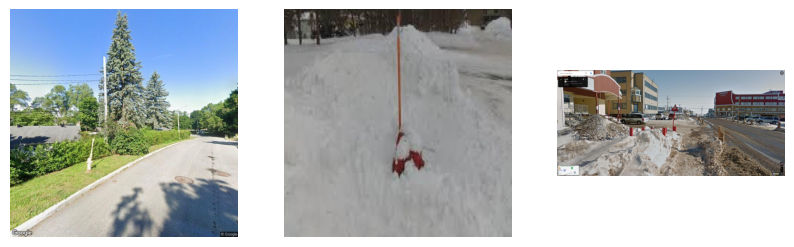


No Fire Hydrant Sample Pictures:


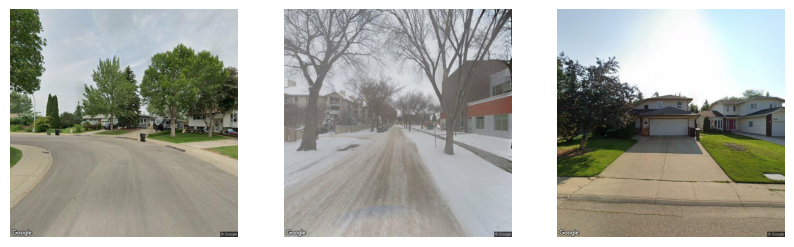


Plot Class Distribution:


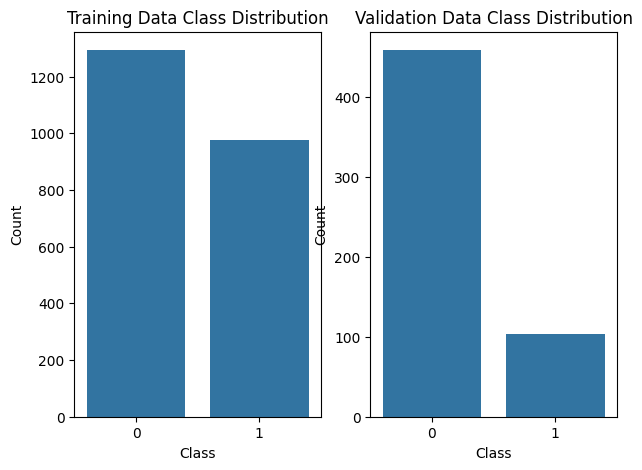

In [44]:
import numpy as np
import seaborn as sns
import cv2
import matplotlib.pyplot as plt
import os
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')
#display first couple rows of dataset info
print("Train Labels:")
print(train_label.head())
print("\nValid Labels:")
print(valid_label.head())

#display sample image
def sample_image(df, path, sample_num=3):
    fig, axes = plt.subplots(1, sample_num, figsize=(10, 5))
    for i, img_name in enumerate(df.sample(sample_num)['filename']):
        img = Image.open(os.path.join(path, img_name))

        axes[i].imshow(img)
        axes[i].axis("off")
    plt.show()

#display three sample pictures from each class
print("\nFire Hydrant Sample Pictures:")
sample_image(train_label[train_label['Fire Hydrants'] == 1], "/content/train")
print("\nNo Fire Hydrant Sample Pictures:")
sample_image(train_label[train_label['Fire Hydrants'] == 0], "/content/train")

train_class_number= train_label['Fire Hydrants'].value_counts()
valid_class_number = valid_label['Fire Hydrants'].value_counts()

#plot class distribution
print("\nPlot Class Distribution:")
plt.figure(figsize=(7, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=train_class_number.index, y=train_class_number.values)
plt.title("Training Data Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.barplot(x=valid_class_number.index, y=valid_class_number.values)
plt.title("Validation Data Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()


---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ one-hot encoding is not necessary for binary classification as the labels are already represented in binary as 0 or 1. Several loss functions can handle and interpret binary labels directly without the need for one-hot encoding. But if cross-entropy is used, one-hot encoding will be needed.

In [46]:
import torchvision.transforms as transforms


train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label_path = '/content/train/_classes.csv'
valid_label_path = '/content/valid/_classes.csv'

# Define Dataset Class
class FireHydrantClass(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.labels = pd.read_csv(csv_file)  #
        self.root_dir = root_dir
        self.transform = transform  # Apply transformations

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.labels.iloc[idx, 0])
        image = Image.open(img_name).convert("RGB")  # Open image and convert to RGB
        label = self.labels.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        return image, label

image_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(), # Convert PIL Image to Tensor
    transforms.Normalize(mean=[0.6], std=[0.6])  # Normalize pixel values
])

# Load datasets
train_dataset = FireHydrantClass(train_label_path, train_data_path, transform=image_transform)
valid_dataset = FireHydrantClass(valid_label_path, valid_data_path, transform=image_transform)

# Create DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset=valid_dataset, batch_size=32, shuffle=False)

---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅ One way to improve baseline model would be to use data augmentation to improve generalization. This is done by increasing the training dataset size by various transformations in order to prevent overfitting.

Another way would be to incorporate learning rate scheduling in order to improve convergence. A models learning rate determines how fast the model updates its weights. By using a scheduler , we can try and reduce the learning rate while training the model to help improve convergence.

One more possible way to improve the baseline model would be to prioritize softmax activation over sigmoid as sigmoid is primarialy used for binary classification and isnt adaptable to adding new classes within the model.

In [47]:
import torch.nn as nn
import torch.optim as optim
import torch
import torchvision
import numpy as np
import seaborn as sns
import cv2
import matplotlib.pyplot as plt
import os
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchsummary import summary
from PIL import Image

#define CNN class
class FireHydrantCNN(nn.Module):
      def __init__(self):
        super(FireHydrantCNN, self).__init__()
        #two convolution layers to extract featuers
        self.convolution1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)  #max pooling between each convolution layers
        self.convolution2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.flatten = nn.Flatten() #flatten before fc
        self.fc1 = nn.Linear(64 * 32 * 32, 128) #Linear layer
        self.fc2 = nn.Linear(128, 1) #output layer
        self.sigmoid = nn.Sigmoid()  #sigmoid activation at the output layer

      def forward(self, x):
        x = self.pool(torch.relu(self.convolution1(x)))
        x = self.pool(torch.relu(self.convolution2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))  #fully connected layer with ReLU
        x = self.sigmoid(self.fc2(x))  #output
        return x

model = FireHydrantCNN()

#move model to available gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#model summary
summary(model, (3, 128, 128))





----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
            Conv2d-3           [-1, 64, 64, 64]          18,496
         MaxPool2d-4           [-1, 64, 32, 32]               0
           Flatten-5                [-1, 65536]               0
            Linear-6                  [-1, 128]       8,388,736
            Linear-7                    [-1, 1]             129
           Sigmoid-8                    [-1, 1]               0
Total params: 8,408,257
Trainable params: 8,408,257
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.19
Forward/backward pass size (MB): 8.00
Params size (MB): 32.07
Estimated Total Size (MB): 40.26
----------------------------------------------------------------


---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ In this model, I think the F1-score is the most suitable evaluation metric. Since our model is based on binary classification, 0s and 1s representing Fire Hydrants and the given dataset is imbalanced as there are a lot more 'No fire hydrant' than 'fire hydrant' , we cannot rely on precision and recall. The F1 score encompasses the precision aspect, how many predicted fire hydrants are actually fire hydrants and recall aspect, how many real fire hydrants are correctly identified from the dataset. Hence the F1-score is the most reliable to evaluate the accuracy of the model.


Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ The confusion matrix is like an overall review of how well our trained model classifys fire hydrants, much like an exam result. It is split into four sections, True Negative - correctly identified as no fire hydrant, False Negative - missed a fire hydrant , False Positive - incorrectly predicted fire hydrant, and True Positive, correctly detected a fire hydrant. Since F1-score is calculated through both precision and recall, we can see the precision of the model through looking at the number of False Positives, if the number is high then precision of the model is low. We can identify the models recall by looking at the number of False Negatives in the confusion matrix, if the number is high then the models recall is low. If both the precision and recall are low, then we can say the model has a low F1-score through the confusion matrix.

In [ ]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import torch.nn as nn
import torch.optim as optim

#define entropy loss and adam optimizer
loss = nn.BCEWithLogitsLoss()
optim = optim.Adam(model.parameters(), lr=0.001)

epochs_no = 10
tracked_losses = []

def training_model(model, train_loader, loss, optim, epochs, device):
    model.train()
    for epoch in range(epochs_no):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)  #move data to GPU if available

            optim.zero_grad()
            outputs = model(images)
            compute_loss = loss(outputs, labels)
            compute_loss.backward()
            optim.step()  #update weights

            running_loss += compute_loss.item()

        epoch_loss = running_loss / len(train_loader)
        tracked_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs_no}, Lossses: {epoch_loss:.4f}")

    print("Training the model has completed.")


training_model(model, train_loader, loss, optim, epochs_no, device)


def model_eval(model, valid_loader, device):
  model.eval() #set model mode
  preds_complete = []
  labels_complete = []

  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.numpy() #convert for eval purposes

      outputs = model(images)
      preds = torch.sigmoid(outputs).cpu().numpy() #apply sigmoid acti and move to cpu
      preds = (preds > 0.5).astype(int) #convert to numeric prob to binary

      preds.complete.extend(preds)
      labels.complete.extend(labels)

  precision = precision_score(labels_complete, preds_complete)
  print(f"Precision: {precision:.4f}")
  recall = recall_score(labels_complete, preds_complete)
  print(f"Recall: {recall:.4f}")
  f1 = f1_score(labels_complete, preds_complete)
  print(f"F1-Score: {f1:.4f}")

  #confusion matrix
  cm = confusion_matrix(labels_complete, preds_complete)
  plt.figure(figsize=(6, 5))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['No Fire Hydrant', 'Fire Hydrant'], yticklabels=['No Fire Hydrant', 'Fire Hydrant'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()



model_eval(model, valid_loader, device)













Epoch 1/10, Lossses: 0.6545
Epoch 2/10, Lossses: 0.6380
Epoch 3/10, Lossses: 0.6430
Epoch 4/10, Lossses: 0.6356
Epoch 5/10, Lossses: 0.6332
Epoch 6/10, Lossses: 0.6330


---


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ Your answer here

In [ ]:
## Enter your code here..

---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ Your answer here

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ Your answer here


In [ ]:
## Enter your code here..

---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ Your answer here..


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ Your answer here..


---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

